In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np


In [3]:
model = load_model('bts_member_recognition_model.h5')

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.optimizers import Adam

In [5]:
model = Sequential([
    # Convolutional base layers (example structure)
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Flatten the output of the convolutional layers
    Flatten(),
    
    # Dense layer with L1 and L2 regularization
    Dense(512, activation='relu', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
    
    # Dropout for regularization
    Dropout(0.5),
    
    # Output layer with softmax activation
    Dense(7, activation='softmax')
])


In [6]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [7]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 74, 74, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 36, 36, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 34, 34, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 17, 17, 128)       0

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
# Assuming your training data is in a directory called 'training_data'
train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    "C:\\Users\\dhars\\Desktop\\BTS_1\\Training Data",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

Found 13440 images belonging to 7 classes.


In [10]:
train_generator.class_indices

{'J Hope': 0, 'Jimin': 1, 'Jin': 2, 'Jungkook': 3, 'RM': 4, 'Suga': 5, 'V': 6}

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)  # Rescaling

# Make sure to replace 'path_to_your_test_directory' with your actual test data path
# Use double backslashes for Windows path or prefix the string with 'r' to avoid escape sequence errors
test_directory = r"C:\Users\dhars\Desktop\BTS_1\Testing Data"

test_generator = test_datagen.flow_from_directory(
    directory=test_directory,
    target_size=(150, 150),  # Adjust based on your model input size
    batch_size=20,  # Can be adjusted based on your needs
    class_mode='categorical',  # 'binary' if it's a binary classification
    shuffle=False)  # Important for evaluation


Found 3360 images belonging to 7 classes.


In [12]:
# from tensorflow.keras.callbacks import EarlyStopping

# # Define early stopping callback
# early_stopping = EarlyStopping(
#     monitor='val_loss',
#     patience=10,
#     restore_best_weights=True
# )

# # Train the model with early stopping
# history = model.fit(
#     train_generator,
#     epochs=50,  # Starting with 50 epochs as an example
#     validation_data=test_generator,
#     callbacks=[early_stopping],
#     verbose=1
# )


In [13]:
# eval_result = model.evaluate(test_generator)
# print(f"Test Loss: {eval_result[0]}, Test Accuracy: {eval_result[1]}")

In [14]:
# After training, save the model to an h5 file
# model.save('model_after_training.h5')

In [15]:
# model.save('C:\\Users\\dhars\\Desktop\\model_after_training.h5')

In [16]:
loaded_model = load_model('model_after_training.h5')

In [17]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Lambda
from tensorflow.keras import backend as K

def initialize_base_network(input_shape):
    """
    Base network to be shared (Siamese).
    """
    input = Input(shape=input_shape)
    x = Conv2D(64, (3, 3), activation='relu')(input)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(128, (3, 3), activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    return Model(inputs=input, outputs=x)

# Define the tensors for the two input images
input_shape = (150, 150, 3)
input_a = Input(shape=input_shape)
input_b = Input(shape=input_shape)

# Create the base network
base_network = initialize_base_network(input_shape)

# Because we re-use the same instance `base_network`,
# the weights of the network will be shared across the two branches
processed_a = base_network(input_a)
processed_b = base_network(input_b)

# Compute the Euclidean distance between the two vectors in the latent space
distance = Lambda(lambda embeddings: K.sqrt(K.sum(K.square(embeddings[0] - embeddings[1]), axis=-1, keepdims=True)))(
    [processed_a, processed_b])

# Add a dense layer with a sigmoid unit to generate the similarity score
similarity = Dense(1, activation='sigmoid')(distance)

# Define the model
model = Model(inputs=[input_a, input_b], outputs=similarity)

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Display the model summary
model.summary()

# Note: You would train this model by feeding pairs of images (input_a, input_b) and a label indicating if they are similar (1) or not (0).



Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 150, 150, 3)]        0         []                            
                                                                                                  
 input_2 (InputLayer)        [(None, 150, 150, 3)]        0         []                            
                                                                                                  
 model (Functional)          (None, 128)                  2130944   ['input_1[0][0]',             
                                                          0          'input_2[0][0]']             
                                                                                                  
 lambda (Lambda)             (None, 1)                    0         ['model[0][0]',        

In [18]:
# Assuming you have a model defined something like this
model = Sequential([
    # Example convolutional base
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    # Add more layers as per your model
    
    Flatten(),
    # Before adding the dense layer, ensure the number of incoming features matches the dense layer's expected input
    Dense(512, activation='relu'),  # This line might need adjustment
    Dense(7, activation='softmax')
])

# Print model summary to check the output shapes at each layer
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 74, 74, 32)        0         
 g2D)                                                            
                                                                 
 flatten_2 (Flatten)         (None, 175232)            0         
                                                                 
 dense_4 (Dense)             (None, 512)               89719296  
                                                                 
 dense_5 (Dense)             (None, 7)                 3591      
                                                                 
Total params: 89723783 (342.27 MB)
Trainable params: 89723783 (342.27 MB)
Non-trainable params: 0 (0.00 Byte)
__________

In [19]:
def contrastive_loss(y_true, y_pred):
    """
    Contrastive loss function.
    :param y_true: True labels (1 for positive pairs, 0 for negative pairs)
    :param y_pred: Predicted distances
    :return: Contrastive loss value
    """
    margin = 1
    square_pred = K.square(y_pred)
    margin_square = K.square(K.maximum(margin - y_pred, 0))
    return K.mean(y_true * square_pred + (1 - y_true) * margin_square)


In [20]:
model.compile(loss=contrastive_loss, optimizer='adam', metrics=['accuracy'])


In [21]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    "C:\\Users\\dhars\\Desktop\\BTS_1\\Testing Data",  # Replace with your test data directory
    target_size=(150, 150),
    batch_size=20,  # Same as in model training if using batch-dependent layers
    class_mode='categorical',
    shuffle=False
)


Found 3360 images belonging to 7 classes.


In [22]:
# Predict the output
predictions = model.predict(test_generator)


168/168 [==============================] - 9s 54ms/step


In [23]:
# Convert predictions from one-hot to labels
predicted_classes = np.argmax(predictions, axis=1)

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
# Get the true labels from the generator
true_classes = test_generator.classes

In [26]:
# Generate the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

In [27]:
class_labels = ['J Hope', 'Jimin', 'Jin', 'Jungkook', 'RM', 'Suga', 'V']

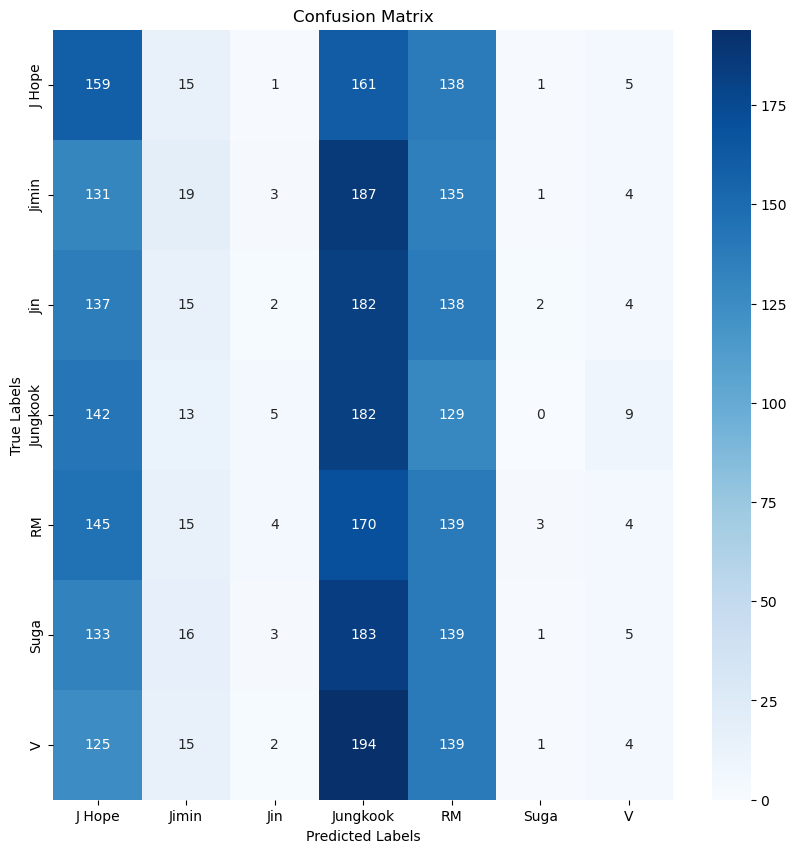

In [28]:
# Plot the confusion matrix
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.show()

In [29]:
from sklearn.metrics import classification_report

In [30]:
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print(report)

              precision    recall  f1-score   support

      J Hope       0.16      0.33      0.22       480
       Jimin       0.18      0.04      0.06       480
         Jin       0.10      0.00      0.01       480
    Jungkook       0.14      0.38      0.21       480
          RM       0.15      0.29      0.19       480
        Suga       0.11      0.00      0.00       480
           V       0.11      0.01      0.02       480

    accuracy                           0.15      3360
   macro avg       0.14      0.15      0.10      3360
weighted avg       0.14      0.15      0.10      3360



In [31]:
from sklearn.metrics import accuracy_score

In [32]:
accuracy = accuracy_score(true_classes, predicted_classes)
print(f'Model Accuracy: {accuracy:.2f}')

Model Accuracy: 0.15


In [33]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

In [34]:
def predict_member(image_path, model):
    # Load the image file, targeting the size expected by the model
    img = image.load_img(image_path, target_size=(150, 150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array /= 255.0  # Rescale the image (as done during training)

    # Predict the class
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction, axis=1)[0]
    
    # Correct the class labels according to the class indices
    class_labels = ['J Hope', 'Jimin', 'Jin', 'Jungkook', 'RM', 'Suga', 'V']

    # Return the predicted class label and the corresponding probability
    return class_labels[predicted_class], np.max(prediction)

In [39]:
# Simulate uploading an image and making a prediction
uploaded_image_path = r"C:\Users\dhars\Desktop\New folder\OIP.jpeg"
predicted_member, probability = predict_member(uploaded_image_path, model)
print(f"Predicted member: {predicted_member}, Probability: {probability:.4f}")

1/1 [==============================] - 0s 40ms/step
Predicted member: J Hope, Probability: 0.1865
